**Ваше завдання — побудувати класифікатор зображень за допомогою Keras і згорткових нейронних мереж (CNN) для набору даних Fashion MNIST. Цей набір даних містить 10 міток різних типів одягу та зображення 28×28 у відтінках сірого. Навчальна вибірка складається з 60 000 зображень, а тестова — з 10 000 зображень.**

    Label	Description
    0	    T-shirt/top
    1	    Trouser
    2	    Pullover
    3	    Dress
    4	    Coat
    5	    Sandal
    6	    Shirt
    7	    Sneaker
    8	    Bag
    9	    Ankle boot

In [3]:
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

**ЗАВДАННЯ 1: Використайте matplotlib, щоб відобразити зображення з набору даних. Це може бути будь-яке зображення з набору даних.**

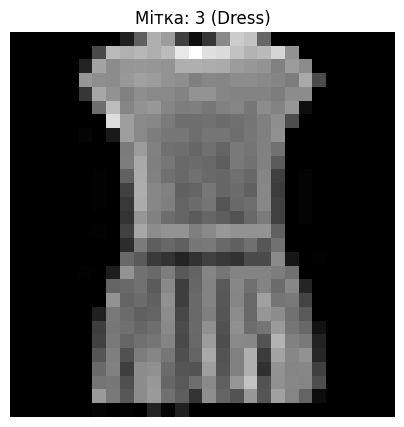

In [ ]:
import matplotlib.pyplot as plt

# текстові назви класів згідно з описом датасету
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# індекс зображення (наприклад, 3 відповідає "Dress")
index = 3

# Створюємо графік
plt.figure(figsize=(5, 5))

# зображення у відтінках сірого
plt.imshow(x_train[index], cmap='gray')

# заголовок, що містить як числову мітку, так і назву класу
plt.title(f"Мітка: {y_train[index]} ({class_names[y_train[index]]})")

plt.axis('off') 

# Виводимо результат на екран
plt.show()

**ЗАВДАННЯ 2: Нормалізуйте дані X_train та X_test, поділивши їх на максимальне значення масивів зображень.**

In [5]:
# максимальне значення пікселя дорівнює 255, тому ділимо на нього
x_train = x_train / 255.0
x_test = x_test / 255.0

# щоб переконатися, що нормалізація пройшла успішно, виводимо максимальне та мінімальне значення:
print(f"Максимальне значення x_train: {x_train.max()}")
print(f"Мінімальне значення x_train: {x_train.min()}")

Максимальне значення x_train: 1.0
Мінімальне значення x_train: 0.0


**ЗАВДАННЯ 3: Змініть форму масивів X, щоб додати четвертий вимір для одного каналу. Аналогічно до того, як ми робили для набору даних MNIST з цифрами.**

In [6]:
# Змінюємо форму (reshape) для x_train та x_test
# 60000 / 10000 - кількість зображень
# 28, 28 - розмір зображення (висота, ширина)
# 1 - кількість каналів кольору (один канал для градацій сірого)

x_train = x_train.reshape(60000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)

# перевіримо нові розмірності:
print("Нова розмірність x_train:", x_train.shape)
print("Нова розмірність x_test:", x_test.shape)

Нова розмірність x_train: (60000, 28, 28, 1)
Нова розмірність x_test: (10000, 28, 28, 1)


**ЗАВДАННЯ 4: Перетворіть значення y_train та y_test у формат one-hot encoding для категоріального аналізу в Keras.**

In [7]:
from tensorflow.keras.utils import to_categorical

# в нас 10 категорій одягу, вказуємо кількість класів = 10
y_cat_train = to_categorical(y_train, 10)
y_cat_test = to_categorical(y_test, 10)

# перевіримо, як змінилися дані на прикладі першого елемента:
print("Оригінальна мітка (y_train[0]):", y_train[0])
print("One-hot мітка (y_cat_train[0]):", y_cat_train[0])

Оригінальна мітка (y_train[0]): 9
One-hot мітка (y_cat_train[0]): [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


**Використайте Keras для створення моделі, яка містить щонайменше такі шари (але можете експериментувати):**

* Згортковий 2D шар (filters = 32, kernel_size = (3,3))
* Шар підвибірки (Pooling), де pool_size = (2,2)

* Шар Flatten
* Повнозв’язний шар Dense (128 нейронів, але можете змінювати це значення), активація ReLU

* Фінальний шар Dense з 10 нейронами та активацією softmax

**Після цього скомпілюйте модель з такими параметрами:
loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy']**

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# 1. створюємо послідовну модель
model = Sequential()

# 2. згортковий 2D шар
# Вказуємо input_shape=(28, 28, 1), оскільки це перший шар у нашій мережі
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))

# 3. шар підвибірки (Max Pooling)
model.add(MaxPooling2D(pool_size=(2, 2)))

# 4. шар Flatten (перетворює 2D матрицю у плоский 1D вектор)
model.add(Flatten())

# 5. повнозв'язний шар Dense (прихований шар)
model.add(Dense(128, activation='relu'))

# 6. фінальний шар Dense (вихідний шар для 10 категорій)
model.add(Dense(10, activation='softmax'))

# 7. компілюємо модель згідно з вашими вимогами
model.compile(loss='categorical_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

# переглянемо структуру створеної моделі
model.summary()

c:\Users\SystemX\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

**ЗАВДАННЯ 5: Натренуйте (fit) модель на наборі x_train. Кількість епох оберіть самостійно.**

In [ ]:
# навчаємо модель
history = model.fit(x_train, y_cat_train, 
                    epochs=10, 
                    validation_data=(x_test, y_cat_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8573 - loss: 0.4009 - val_accuracy: 0.8891 - val_loss: 0.3104
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9039 - loss: 0.2686 - val_accuracy: 0.9038 - val_loss: 0.2696
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9171 - loss: 0.2284 - val_accuracy: 0.9063 - val_loss: 0.2682
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9277 - loss: 0.1995 - val_accuracy: 0.9044 - val_loss: 0.2810
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9358 - loss: 0.1781 - val_accuracy: 0.9099 - val_loss: 0.2675
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9413 - loss: 0.1604 - val_accuracy: 0.9130 - val_loss: 0.2806
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9470 - loss: 0.1451 - val_accuracy: 0.9167 - val_loss: 0.2742
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9524 - loss: 0.1321 - 

**ЗАВДАННЯ 6: Виведіть метрики accuracy, precision, recall, f1-score, яких модель досягла на тестовому наборі x_test.
Зверніть увагу, що є багато способів це зробити, але ми рекомендуємо використати ту саму процедуру, яку розглядали на лекції з MNIST.**

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# 1. Отримуємо передбачення моделі.
# model.predict видає масив ймовірностей для кожного з 10 класів.
# np.argmax обирає індекс класу, ймовірність якого найбільша.
predictions = np.argmax(model.predict(x_test), axis=1)

# 2. звіт з усіма метриками
# Порівнюємо справжні мітки (y_test) з нашими передбаченнями (predictions)
print(classification_report(y_test, predictions))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 920us/step
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1000
           1       1.00      0.98      0.99      1000
           2       0.77      0.92      0.84      1000
           3       0.93      0.90      0.92      1000
           4       0.93      0.74      0.82      1000
           5       0.99      0.98      0.98      1000
           6       0.77      0.76      0.77      1000
           7       0.93      0.98      0.96      1000
           8       0.98      0.98      0.98      1000
           9       0.98      0.94      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



### Висновки

У ході виконання практичної роботи було успішно побудовано та натреновано згорткову нейронну мережу (**CNN**) для класифікації зображень одягу з датасету **Fashion MNIST**, яка досягла високої загальної точності у **91%** на тестовій вибірці. 

**Аналіз отриманих метрик показав:**
* Модель відмінно та майже безпомилково розпізнає об'єкти з унікальними формами (штани, сумки, взуття).
* Очікувано виникають незначні труднощі при розрізненні візуально схожих категорій верхнього одягу (сорочки, светри, футболки) через їхню подібність на чорно-білих піксельних зображеннях низької роздільної здатності (28x28). 

Загалом, результати підтверджують високу ефективність та доцільність використання базових архітектур згорткових нейромереж для вирішення завдань комп'ютерного зору та розпізнавання образів.